In [1]:
# ============================================
# PREPROCESSING & MODEL PREPARATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================
# LOAD FINAL DATASET
# ============================================

df = pd.read_csv("../data/bengaluru_resale_10000.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (10000, 25)


,row_id,listingId,title,price,area_sqft,bhk,bathrooms,parking,location,city,...,facing,age_years,possession_category,possession_date,is_under_construction,project_name,posted_date,propertyType,saleTag,data_source
0,ROW_00001,SYN_01254,NaN,25190000.0,1531.0,3.0,2,1,"Ambedkar Colony, Yelahanka",NaN,...,West,4.0,Ready to Move,NaN,False,NaN,NaN,NaN,NaN,Synthetic
1,ROW_00002,REAL_20721589,2.5 BHK Flat,17000000.0,1280.0,2.5,2,1,"Anjanadri Layout, Konanakunte",Bengaluru,...,South,6.0,Ready to Move,NaN,False,NaN,2026-07-17,resale,Resale,Real
2,ROW_00003,REAL_19161091,4 BHK Flat,95000000.0,3500.0,4.0,4,3,"Mahantara Lay Out, Kempegowda Nagar",Bengaluru,...,North,7.0,Ready to Move,NaN,False,Svasa Homes,2026-07-24,resale,Resale,Real
3,ROW_00004,REAL_20484165,3 BHK Flat,21500000.0,1350.0,3.0,3,1,"Carmelaram, Bengaluru",Bengaluru,...,West,2.0,Ready to Move,NaN,False,DSR Parkway,2026-08-29,resale,Resale,Real
4,ROW_00005,REAL_21087605,2 BHK Flat,15800000.0,1334.0,2.0,2,1,"Dodsworth Layout, Whitefield",Bengaluru,...,East,15.0,Ready to Move,NaN,False,White Field Ville,2026-09-10,resale,Resale,Real


In [3]:
# ============================================
# DATASET OVERVIEW
# ============================================

print("Number of records:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("data_type"))

Number of records: 10000
Number of columns: 25

Columns:
['row_id', 'listingId', 'title', 'price', 'area_sqft', 'bhk', 'bathrooms', 'parking', 'location', 'city', 'latitude', 'longitude', 'floor_number', 'total_floors', 'furnishing', 'facing', 'age_years', 'possession_category', 'possession_date', 'is_under_construction', 'project_name', 'posted_date', 'propertyType', 'saleTag', 'data_source']

Data types:


,data_type
row_id,str
listingId,str
title,str
price,float64
area_sqft,float64
bhk,float64
bathrooms,int64
parking,int64
location,str
city,str


In [4]:
# ============================================
# MISSING VALUE CHECK
# ============================================

missing_summary = (
    df.isnull()
      .sum()
      .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df) * 100
)

missing_summary = missing_summary.sort_values(
    "missing_count",
    ascending=False
)

display(missing_summary)

,missing_count,missing_percentage
possession_date,8819,88.19
project_name,5781,57.81
posted_date,5012,50.12
title,5001,50.01
saleTag,5001,50.01
propertyType,5001,50.01
city,5001,50.01
latitude,5001,50.01
longitude,5001,50.01
age_years,1266,12.66


In [5]:
# ============================================
# DEFINE TARGET VARIABLE
# ============================================

target = "price"

print("Target variable:", target)
print("Target data type:", df[target].dtype)

display(df[target].describe())

Target variable: price
Target data type: float64


count    1.000000e+04
mean     1.937733e+07
std      1.606211e+07
min      2.000000e+06
25%      1.130000e+07
50%      1.587000e+07
75%      2.350000e+07
max      7.000000e+08
Name: price, dtype: float64

In [6]:
# ============================================
# SELECT MODEL FEATURES
# ============================================

numeric_features = [
    "area_sqft",
    "bhk",
    "bathrooms",
    "parking",
    "floor_number",
    "total_floors",
    "age_years"
]

categorical_features = [
    "location",
    "furnishing",
    "facing",
    "possession_category",
    "is_under_construction"
]

features = numeric_features + categorical_features

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal model features:", len(features))

Numerical features:
['area_sqft', 'bhk', 'bathrooms', 'parking', 'floor_number', 'total_floors', 'age_years']

Categorical features:
['location', 'furnishing', 'facing', 'possession_category', 'is_under_construction']

Total model features: 12


In [7]:
# ============================================
# VERIFY SELECTED FEATURES
# ============================================

model_df = df[features + [target]].copy()

print("Model dataset shape:", model_df.shape)

display(model_df.head())

print("\nMissing values in selected features:")
display(
    model_df.isnull()
            .sum()
            .sort_values(ascending=False)
            .to_frame("missing_count")
)

Model dataset shape: (10000, 13)


,area_sqft,bhk,bathrooms,parking,floor_number,total_floors,age_years,location,furnishing,facing,possession_category,is_under_construction,price
0,1531.0,3.0,2,1,11.0,14.0,4.0,"Ambedkar Colony, Yelahanka",Unfurnished,West,Ready to Move,False,25190000.0
1,1280.0,2.5,2,1,10.0,15.0,6.0,"Anjanadri Layout, Konanakunte",Semi Furnished,South,Ready to Move,False,17000000.0
2,3500.0,4.0,4,3,11.0,21.0,7.0,"Mahantara Lay Out, Kempegowda Nagar",Unfurnished,North,Ready to Move,False,95000000.0
3,1350.0,3.0,3,1,8.0,15.0,2.0,"Carmelaram, Bengaluru",Semi Furnished,West,Ready to Move,False,21500000.0
4,1334.0,2.0,2,1,3.0,4.0,15.0,"Dodsworth Layout, Whitefield",Semi Furnished,East,Ready to Move,False,15800000.0



Missing values in selected features:


,missing_count
age_years,1266
floor_number,51
total_floors,51
area_sqft,0
bhk,0
bathrooms,0
parking,0
location,0
furnishing,0
facing,0


In [8]:
# ============================================
# SEPARATE FEATURES AND TARGET
# ============================================

X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 12)
y shape: (10000,)


In [9]:
# ============================================
# TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining percentage:", len(X_train) / len(X) * 100)
print("Testing percentage:", len(X_test) / len(X) * 100)

Training records: 8000
Testing records: 2000

Training percentage: 80.0
Testing percentage: 20.0


In [10]:
# ============================================
# NUMERICAL PREPROCESSING
# ============================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [11]:
# ============================================
# CATEGORICAL PREPROCESSING
# ============================================

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [12]:
# ============================================
# COMBINE PREPROCESSING
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Combined preprocessing pipeline created.")

Combined preprocessing pipeline created.


In [13]:
# ============================================
# FIT PREPROCESSOR
# ============================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:")
print("Shape:", X_train_processed.shape)

print("\nTesting data after preprocessing:")
print("Shape:", X_test_processed.shape)

Training data after preprocessing:
Shape: (8000, 765)

Testing data after preprocessing:
Shape: (2000, 765)


In [14]:
# ============================================
# VERIFY PREPROCESSING
# ============================================

print("Preprocessing completed successfully.")

print("\nOriginal training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Preprocessing completed successfully.

Original training shape: (8000, 12)
Processed training shape: (8000, 765)

Original testing shape: (2000, 12)
Processed testing shape: (2000, 765)


In [15]:
# ============================================
# REGRESSION MODELS
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print("Regression models imported.")

Regression models imported.


In [16]:
# ============================================
# DEFINE REGRESSION MODELS
# ============================================

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("Models prepared:")
for name in models:
    print("-", name)

Models prepared:
- Linear Regression
- Random Forest
- Gradient Boosting


In [17]:
# ============================================
# CREATE MODEL PIPELINES
# ============================================

model_pipelines = {}

for name, model in models.items():

    model_pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Model pipelines created successfully.")

for name in model_pipelines:
    print("-", name)

Model pipelines created successfully.
- Linear Regression
- Random Forest
- Gradient Boosting


In [18]:
# ============================================
# TRAIN MODELS
# ============================================

for name, pipeline in model_pipelines.items():

    print(f"Training {name}...")

    pipeline.fit(X_train, y_train)

    print(f"{name} training completed.")

print("\nAll models trained successfully.")

Training Linear Regression...
Linear Regression training completed.
Training Random Forest...
Random Forest training completed.
Training Gradient Boosting...
Gradient Boosting training completed.

All models trained successfully.


In [20]:
# MODEL EVALUATION

evaluation_results = []

for name, pipeline in model_pipelines.items():
    
    # Predictions on test data
    y_pred = pipeline.predict(X_test)
    
    # Evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    evaluation_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

# Create results table
evaluation_df = pd.DataFrame(evaluation_results)

# Display
display(evaluation_df)

,Model,MAE,RMSE,R²
0,Linear Regression,4.089047e+06,6.694858e+06,0.796950
1,Random Forest,3.992819e+06,8.890919e+06,0.641893
2,Gradient Boosting,4.255625e+06,9.199872e+06,0.616572


In [21]:
# FORMATTED MODEL COMPARISON

evaluation_display = evaluation_df.copy()

evaluation_display["MAE"] = evaluation_display["MAE"].apply(
    lambda x: f"₹{x:,.0f}"
)

evaluation_display["RMSE"] = evaluation_display["RMSE"].apply(
    lambda x: f"₹{x:,.0f}"
)

evaluation_display["R²"] = evaluation_display["R²"].round(4)

display(evaluation_display)

,Model,MAE,RMSE,R²
0,Linear Regression,"₹4,089,047","₹6,694,858",0.7970
1,Random Forest,"₹3,992,819","₹8,890,919",0.6419
2,Gradient Boosting,"₹4,255,625","₹9,199,872",0.6166


In [23]:
# ACTUAL VS PREDICTED PRICE

# Use the selected Linear Regression model
best_model = model_pipelines["Linear Regression"]

# Generate predictions on the test set
y_pred = best_model.predict(X_test)

# Create comparison dataframe
prediction_df = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": y_pred
})

display(prediction_df.head(10))

,Actual_Price,Predicted_Price
0,16030000.0,2.082480e+07
1,18600000.0,1.207302e+07
2,20000000.0,1.432652e+07
3,25970000.0,3.046140e+07
4,19000000.0,2.637338e+07
5,27850000.0,4.027776e+07
6,5610000.0,5.145716e+06
7,43370000.0,3.226637e+07
8,11640000.0,1.572457e+07
9,28220000.0,2.117247e+07


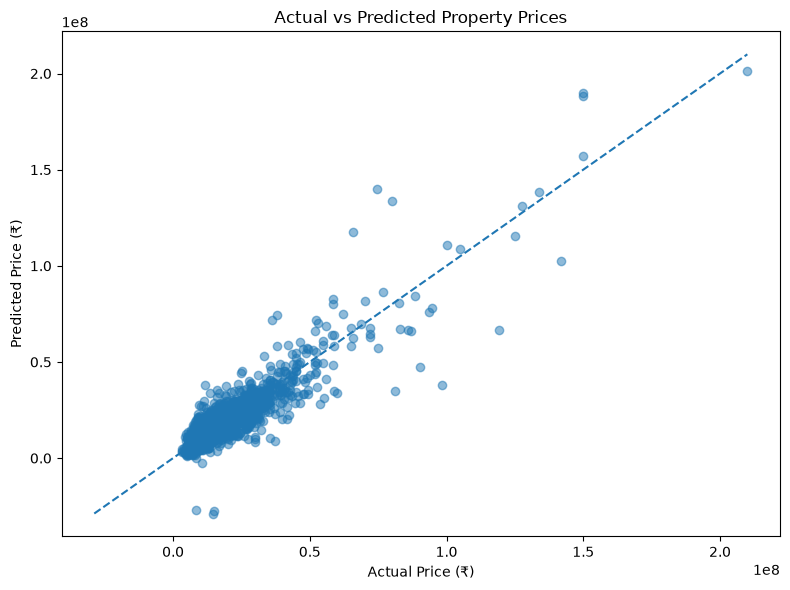

In [24]:
# ACTUAL VS PREDICTED PRICE PLOT

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_df["Actual_Price"],
    prediction_df["Predicted_Price"],
    alpha=0.5
)

# Perfect prediction reference line
min_price = min(
    prediction_df["Actual_Price"].min(),
    prediction_df["Predicted_Price"].min()
)

max_price = max(
    prediction_df["Actual_Price"].max(),
    prediction_df["Predicted_Price"].max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title("Actual vs Predicted Property Prices")
plt.tight_layout()
plt.show()

In [25]:
# RESIDUAL / PREDICTION ERROR ANALYSIS

prediction_df["Residual"] = (
    prediction_df["Actual_Price"] -
    prediction_df["Predicted_Price"]
)

prediction_df["Absolute_Error"] = (
    prediction_df["Residual"].abs()
)

prediction_df["Percentage_Error"] = (
    prediction_df["Absolute_Error"] /
    prediction_df["Actual_Price"]
) * 100

display(
    prediction_df[
        [
            "Actual_Price",
            "Predicted_Price",
            "Residual",
            "Absolute_Error",
            "Percentage_Error"
        ]
    ].head(10)
)

,Actual_Price,Predicted_Price,Residual,Absolute_Error,Percentage_Error
0,16030000.0,2.082480e+07,-4.794798e+06,4.794798e+06,29.911403
1,18600000.0,1.207302e+07,6.526979e+06,6.526979e+06,35.091286
2,20000000.0,1.432652e+07,5.673480e+06,5.673480e+06,28.367402
3,25970000.0,3.046140e+07,-4.491402e+06,4.491402e+06,17.294577
4,19000000.0,2.637338e+07,-7.373384e+06,7.373384e+06,38.807285
5,27850000.0,4.027776e+07,-1.242776e+07,1.242776e+07,44.623919
6,5610000.0,5.145716e+06,4.642839e+05,4.642839e+05,8.276005
7,43370000.0,3.226637e+07,1.110363e+07,1.110363e+07,25.602087
8,11640000.0,1.572457e+07,-4.084569e+06,4.084569e+06,35.090798
9,28220000.0,2.117247e+07,7.047530e+06,7.047530e+06,24.973529


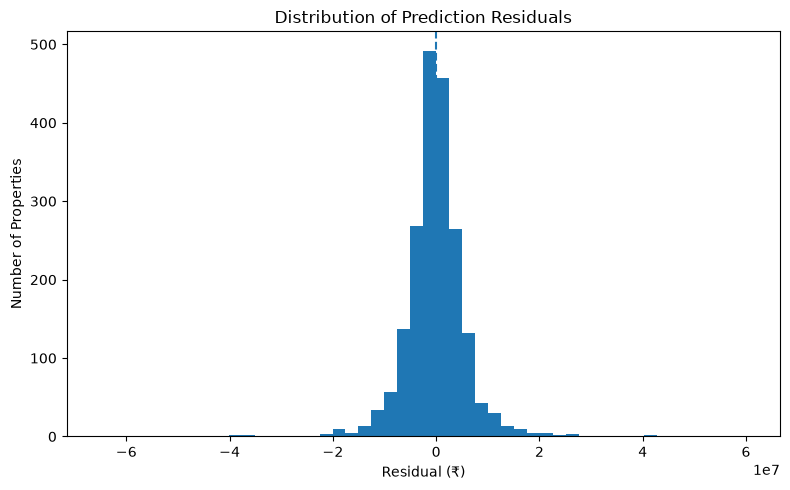

In [26]:
# RESIDUAL DISTRIBUTION

plt.figure(figsize=(8, 5))

plt.hist(
    prediction_df["Residual"],
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (₹)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Prediction Residuals")
plt.tight_layout()
plt.show()

Percentage Error Statistics
count    2000.000000
mean       24.098797
std        27.458940
min         0.002046
50%        16.321078
75%        31.435105
90%        52.391035
95%        71.529335
97.5%      94.242648
99%       122.011185
max       424.670423
Name: Percentage_Error, dtype: float64


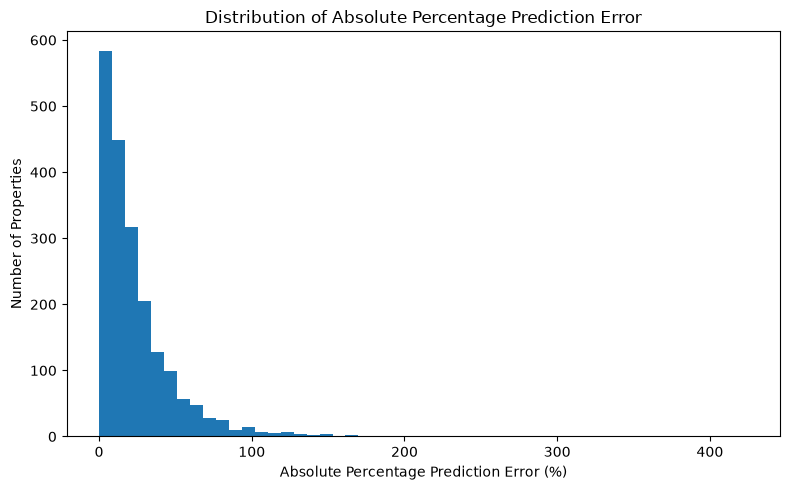

In [27]:
# PERCENTAGE ERROR DISTRIBUTION

print("Percentage Error Statistics")
print("=" * 50)

print(prediction_df["Percentage_Error"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.975, 0.99]
))

plt.figure(figsize=(8, 5))

plt.hist(
    prediction_df["Percentage_Error"],
    bins=50
)

plt.xlabel("Absolute Percentage Prediction Error (%)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Absolute Percentage Prediction Error")
plt.tight_layout()
plt.show()

In [28]:
# KEY ERROR PERCENTILES

error_percentiles = prediction_df["Percentage_Error"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.975, 0.99]
)

display(
    error_percentiles.to_frame("Percentage_Error")
)

,Percentage_Error
0.500,16.321078
0.750,31.435105
0.900,52.391035
0.950,71.529335
0.975,94.242648
0.990,122.011185


In [29]:
# SIGNED PRICE DEVIATION FROM MODEL PREDICTION

prediction_df["Deviation_Percentage"] = (
    (prediction_df["Actual_Price"] - prediction_df["Predicted_Price"])
    / prediction_df["Predicted_Price"]
) * 100

print("Signed Deviation Statistics")
print("=" * 50)

print(
    prediction_df["Deviation_Percentage"].describe(
        percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

Signed Deviation Statistics
count    2000.000000
mean        8.465549
std       120.745100
min      -554.695520
5%        -40.647139
10%       -31.253739
25%       -14.777494
50%        -0.795822
75%        18.443120
90%        45.428051
95%        72.169396
max      5039.913602
Name: Deviation_Percentage, dtype: float64


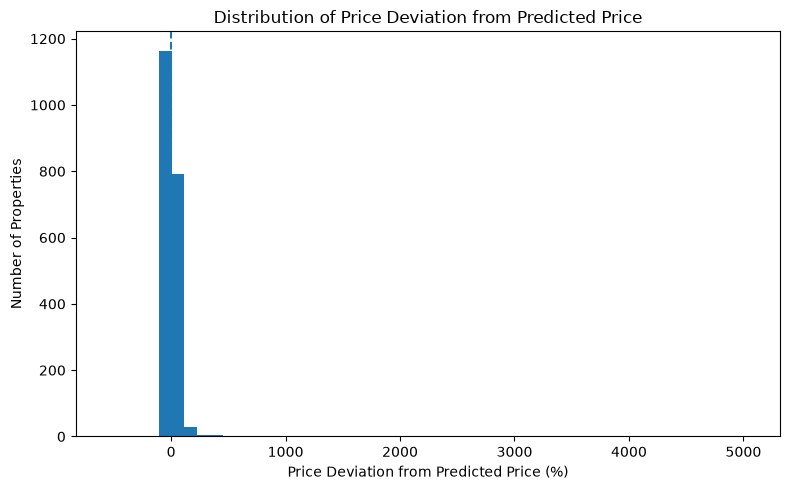

In [30]:
# SIGNED DEVIATION DISTRIBUTION

plt.figure(figsize=(8, 5))

plt.hist(
    prediction_df["Deviation_Percentage"],
    bins=50
)

plt.axvline(0, linestyle="--")

plt.xlabel("Price Deviation from Predicted Price (%)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Price Deviation from Predicted Price")

plt.tight_layout()
plt.show()

In [31]:
# SIGNED PERCENTAGE ERROR
# Actual price is used as the denominator to avoid instability
# when predicted price is very small.

prediction_df["Signed_Percentage_Error"] = (
    (prediction_df["Actual_Price"] - prediction_df["Predicted_Price"])
    / prediction_df["Actual_Price"]
) * 100

print("Signed Percentage Error Statistics")
print("=" * 50)

print(
    prediction_df["Signed_Percentage_Error"].describe(
        percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

Signed Percentage Error Statistics
count    2000.000000
mean       -3.781475
std        36.341838
min      -224.280834
5%        -67.350126
10%       -44.631566
25%       -17.176305
50%        -0.589519
75%        15.730163
90%        31.538868
95%        42.283829
max       424.670423
Name: Signed_Percentage_Error, dtype: float64


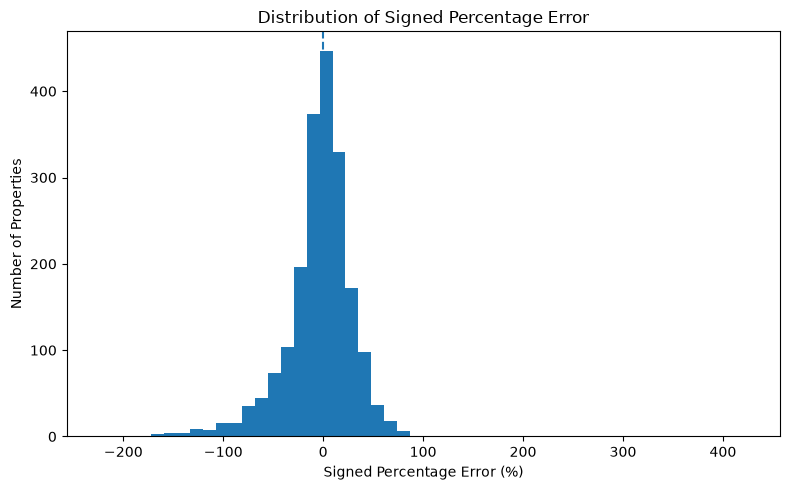

In [32]:
# DISTRIBUTION OF SIGNED PERCENTAGE ERROR

plt.figure(figsize=(8, 5))

plt.hist(
    prediction_df["Signed_Percentage_Error"],
    bins=50
)

plt.axvline(0, linestyle="--")

plt.xlabel("Signed Percentage Error (%)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Signed Percentage Error")

plt.tight_layout()
plt.show()

In [34]:
from sklearn.model_selection import KFold, cross_val_predict

# Use the same Linear Regression pipeline selected during evaluation
linear_pipeline = model_pipelines["Linear Regression"]

# 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold predictions
# Each property is predicted by a model that was NOT trained on that property
oof_predictions = cross_val_predict(
    linear_pipeline,
    X,
    y,
    cv=kf,
    n_jobs=-1
)

print("Out-of-fold predictions generated successfully.")
print("Number of predictions:", len(oof_predictions))

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.che

Out-of-fold predictions generated successfully.
Number of predictions: 10000


In [35]:
# FULL DATASET PREDICTIONS

anomaly_df = df.copy()

anomaly_df["Predicted_Price"] = oof_predictions

anomaly_df["Residual"] = (
    anomaly_df["price"] -
    anomaly_df["Predicted_Price"]
)

anomaly_df["Absolute_Error"] = (
    anomaly_df["Residual"].abs()
)

# Signed percentage deviation
anomaly_df["Signed_Percentage_Error"] = (
    (anomaly_df["price"] - anomaly_df["Predicted_Price"])
    / anomaly_df["price"]
) * 100

print("Prediction dataset created.")
print("Shape:", anomaly_df.shape)

display(
    anomaly_df[
        [
            "price",
            "Predicted_Price",
            "Residual",
            "Absolute_Error",
            "Signed_Percentage_Error"
        ]
    ].head(10)
)

Prediction dataset created.
Shape: (10000, 29)


,price,Predicted_Price,Residual,Absolute_Error,Signed_Percentage_Error
0,25190000.0,2.267515e+07,2.514852e+06,2.514852e+06,9.983532
1,17000000.0,2.592678e+07,-8.926785e+06,8.926785e+06,-52.510498
2,95000000.0,8.763823e+07,7.361770e+06,7.361770e+06,7.749232
3,21500000.0,1.601314e+07,5.486856e+06,5.486856e+06,25.520261
4,15800000.0,1.485417e+07,9.458318e+05,9.458318e+05,5.986277
5,14420000.0,1.622822e+07,-1.808223e+06,1.808223e+06,-12.539690
6,7200000.0,2.607776e+06,4.592224e+06,4.592224e+06,63.780884
7,21090000.0,2.893619e+07,-7.846186e+06,7.846186e+06,-37.203347
8,13870000.0,9.061345e+06,4.808655e+06,4.808655e+06,34.669464
9,12000000.0,1.263109e+07,-6.310940e+05,6.310940e+05,-5.259116


In [36]:
# OUT-OF-FOLD ERROR DISTRIBUTION

print("Out-of-Fold Signed Percentage Error")
print("=" * 50)

print(
    anomaly_df["Signed_Percentage_Error"].describe(
        percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

Out-of-Fold Signed Percentage Error
count    10000.000000
mean        -5.048536
std         36.391744
min      -1160.053568
5%         -68.434435
10%        -44.217661
25%        -16.772718
50%         -0.232257
75%         13.669580
90%         27.870004
95%         38.413181
max        424.765547
Name: Signed_Percentage_Error, dtype: float64


In [37]:
# DATA-DRIVEN ANOMALY THRESHOLDS

lower_threshold = anomaly_df["Signed_Percentage_Error"].quantile(0.05)
upper_threshold = anomaly_df["Signed_Percentage_Error"].quantile(0.95)

print("Anomaly Thresholds")
print("=" * 50)
print(f"Underpriced threshold : {lower_threshold:.2f}%")
print(f"Overpriced threshold  : {upper_threshold:.2f}%")
print(f"Fairly Priced range   : {lower_threshold:.2f}% to {upper_threshold:.2f}%")

Anomaly Thresholds
Underpriced threshold : -68.43%
Overpriced threshold  : 38.41%
Fairly Priced range   : -68.43% to 38.41%


In [38]:
# PRICE ANOMALY CLASSIFICATION

def classify_price(deviation):
    if deviation < lower_threshold:
        return "Underpriced"
    elif deviation > upper_threshold:
        return "Overpriced"
    else:
        return "Fairly Priced"


anomaly_df["Price_Category"] = (
    anomaly_df["Signed_Percentage_Error"]
    .apply(classify_price)
)

print("Price anomaly classification completed.")

Price anomaly classification completed.


In [39]:
# PRICE CATEGORY DISTRIBUTION

category_counts = (
    anomaly_df["Price_Category"]
    .value_counts()
    .reindex(["Underpriced", "Fairly Priced", "Overpriced"])
)

category_percentages = (
    category_counts / len(anomaly_df) * 100
).round(2)

category_summary = pd.DataFrame({
    "Count": category_counts,
    "Percentage": category_percentages
})

display(category_summary)

,Count,Percentage
Price_Category,,
Underpriced,500,5.0
Fairly Priced,9000,90.0
Overpriced,500,5.0


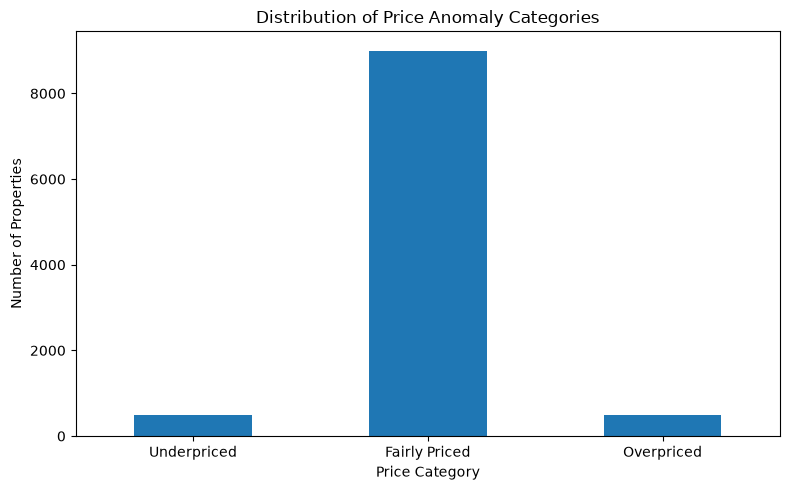

In [40]:
# PRICE ANOMALY CATEGORY DISTRIBUTION

plt.figure(figsize=(8, 5))

category_counts.plot(kind="bar")

plt.xlabel("Price Category")
plt.ylabel("Number of Properties")
plt.title("Distribution of Price Anomaly Categories")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
# EXAMPLE PROPERTIES FROM EACH CATEGORY

display_columns = [
    "price",
    "Predicted_Price",
    "Signed_Percentage_Error",
    "Price_Category",
    "area_sqft",
    "bhk",
    "bathrooms",
    "parking",
    "location",
    "furnishing"
]

print("UNDERPRICED PROPERTIES")
display(
    anomaly_df[
        anomaly_df["Price_Category"] == "Underpriced"
    ][display_columns]
    .sort_values("Signed_Percentage_Error")
    .head(10)
)

print("FAIRLY PRICED PROPERTIES")
display(
    anomaly_df[
        anomaly_df["Price_Category"] == "Fairly Priced"
    ][display_columns]
    .sort_values("Signed_Percentage_Error")
    .head(10)
)

print("OVERPRICED PROPERTIES")
display(
    anomaly_df[
        anomaly_df["Price_Category"] == "Overpriced"
    ][display_columns]
    .sort_values("Signed_Percentage_Error", ascending=False)
    .head(10)
)

UNDERPRICED PROPERTIES


,price,Predicted_Price,Signed_Percentage_Error,Price_Category,area_sqft,bhk,bathrooms,parking,location,furnishing
3248,47340000.0,5.965094e+08,-1160.053568,Underpriced,2648.0,4.0,4,3,"D Souza Layout, Lavelle Road",Fully Furnished
8116,6110000.0,5.276875e+07,-763.645744,Underpriced,926.0,2.0,2,2,"Dena Bank Colony, Ganganagar",Semi Furnished
7170,6360000.0,2.903050e+07,-356.454463,Underpriced,1166.0,2.0,2,0,"Gottigere, Bengaluru",Semi Furnished
8258,24310000.0,8.979108e+07,-269.358602,Underpriced,2015.0,4.0,4,2,"Hebbal, Bengaluru",Unfurnished
8432,4844000.0,1.578897e+07,-225.949044,Underpriced,1390.0,3.0,3,0,"Rajiv Gandhi Nagar, Kodigehalli",Semi Furnished
1791,11750000.0,3.745399e+07,-218.757364,Underpriced,1508.0,3.0,2,1,"Vasanth Nagar, Bengaluru",Semi Furnished
2117,11000000.0,3.397699e+07,-208.881745,Underpriced,2200.0,4.0,5,1,"Banakshankari 6th Stage 11th Block, Srinivaspura",Semi Furnished
5442,10500000.0,3.071255e+07,-192.500435,Underpriced,1300.0,2.0,2,1,"Nagashetty Halli, RMV Extension Stage 2",Semi Furnished
893,12000000.0,3.491559e+07,-190.963280,Underpriced,1700.0,3.0,2,1,"Vaikuntam Layout, Munnekollal",Unfurnished
247,2000000.0,5.797998e+06,-189.899904,Underpriced,400.0,1.0,1,0,"MIG Flats, Kengeri Satellite Town",Unfurnished


FAIRLY PRICED PROPERTIES


,price,Predicted_Price,Signed_Percentage_Error,Price_Category,area_sqft,bhk,bathrooms,parking,location,furnishing
8437,7640000.0,1.286835e+07,-68.433842,Fairly Priced,1189.0,2.0,2,1,"Budigere Cross, Bengaluru",Semi Furnished
4909,21600000.0,3.637803e+07,-68.416785,Fairly Priced,1381.0,3.0,3,1,"Candeur Landmark, Halasahalli",Semi Furnished
4531,13090000.0,2.204567e+07,-68.416148,Fairly Priced,1198.0,2.0,2,1,"Nagavarapalya, C V Raman Nagar",Semi Furnished
2269,9500000.0,1.599596e+07,-68.378568,Fairly Priced,1256.0,2.0,2,1,"Industrial Area, Yelahanka New Town",Semi Furnished
2745,7200000.0,1.212208e+07,-68.362241,Fairly Priced,1117.0,2.0,2,1,"V. Kallahalli, Bengaluru",Semi Furnished
5908,9500000.0,1.598726e+07,-68.286987,Fairly Priced,1400.0,3.0,3,1,"Ramanashree California Gardens Layout, Bengaluru",Semi Furnished
7531,11460000.0,1.927215e+07,-68.168850,Fairly Priced,1634.0,3.0,3,2,"Sarjapur, Bengaluru",Semi Furnished
4025,6800000.0,1.142946e+07,-68.080242,Fairly Priced,1009.0,2.0,2,2,"Doddaballapura, Bengaluru",Unfurnished
9326,18000000.0,3.023673e+07,-67.981830,Fairly Priced,1281.0,2.0,2,1,"Kariyammana Agrahara, Bellandur",Semi Furnished
1285,80000000.0,1.342779e+08,-67.847367,Fairly Priced,7700.0,4.0,4,3,"Sathya Sai Layout, Whitefield",Semi Furnished


OVERPRICED PROPERTIES


,price,Predicted_Price,Signed_Percentage_Error,Price_Category,area_sqft,bhk,bathrooms,parking,location,furnishing
9892,8370000.0,-2.718288e+07,424.765547,Overpriced,1114.0,2.0,2,1,"Sanjay Nagar, Marathahalli",Unfurnished
3556,8000000.0,-1.874170e+07,334.271230,Overpriced,1085.0,2.0,2,1,"Venkataswara Layout, Munnekollal",Semi Furnished
1315,14490000.0,-2.884013e+07,299.034736,Overpriced,1098.0,2.0,2,1,"Sanjay Nagar, Marathahalli",Semi Furnished
9391,15000000.0,-2.736263e+07,282.417529,Overpriced,1150.0,2.0,2,1,"Sanjay Nagar, Marathahalli",Semi Furnished
8345,3880000.0,-2.535117e+06,165.338068,Overpriced,739.0,2.0,2,1,"Horamavu Agara, Horamavu",Unfurnished
450,10400000.0,-2.651393e+06,125.494168,Overpriced,1400.0,4.0,3,2,"Bohra Layout, Gottigere",Semi Furnished
4880,11180000.0,-9.539207e+05,108.532386,Overpriced,1031.0,3.0,3,1,"RV Vidyaniketan, Mailasandra",Unfurnished
245,8500000.0,-6.171714e+04,100.726084,Overpriced,840.0,2.0,2,1,"Venkateshwara Layout, Panduranga Nagar",Semi Furnished
5588,7300000.0,3.830014e+04,99.475341,Overpriced,432.0,1.0,1,1,"Shriram Sameeksha, Singapura",Unfurnished
1016,6600000.0,8.863056e+05,86.571128,Overpriced,927.0,2.0,2,1,"Hennagara, Bommasandra",Semi Furnished


In [51]:
# CHECK OUT-OF-FOLD PREDICTION QUALITY

print("Out-of-Fold Prediction Quality Check")
print("=" * 55)

negative_predictions = (
    anomaly_df["Predicted_Price"] < 0
).sum()

zero_predictions = (
    anomaly_df["Predicted_Price"] == 0
).sum()

print(f"Total properties: {len(anomaly_df):,}")
print(f"Negative predictions: {negative_predictions:,}")
print(f"Zero predictions: {zero_predictions:,}")

print("\nPrediction statistics:")
display(
    anomaly_df["Predicted_Price"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

Out-of-Fold Prediction Quality Check
Total properties: 10,000
Negative predictions: 8
Zero predictions: 0

Prediction statistics:


count    1.000000e+04
mean     1.942116e+07
std      1.487093e+07
min     -2.884013e+07
1%       3.451677e+06
5%       6.513836e+06
25%      1.165482e+07
50%      1.645959e+07
75%      2.333252e+07
95%      3.922705e+07
99%      6.687847e+07
max      5.965094e+08
Name: Predicted_Price, dtype: float64

In [52]:
# CHECK EXTREME OOF PREDICTIONS

print("Highest predicted prices:")
display(
    anomaly_df[
        [
            "price",
            "Predicted_Price",
            "Signed_Percentage_Error",
            "area_sqft",
            "bhk",
            "location"
        ]
    ]
    .sort_values("Predicted_Price", ascending=False)
    .head(10)
)

print("\nLowest predicted prices:")
display(
    anomaly_df[
        [
            "price",
            "Predicted_Price",
            "Signed_Percentage_Error",
            "area_sqft",
            "bhk",
            "location"
        ]
    ]
    .sort_values("Predicted_Price")
    .head(10)
)

Highest predicted prices:


,price,Predicted_Price,Signed_Percentage_Error,area_sqft,bhk,location
3248,47340000.0,5.965094e+08,-1160.053568,2648.0,4.0,"D Souza Layout, Lavelle Road"
1873,236930000.0,2.315910e+08,2.253425,8945.0,5.0,"One Bangalore West, Rajajinagar"
4147,300000000.0,2.223478e+08,25.884080,8350.0,5.0,"One Bangalore West, Rajajinagar"
9119,322500000.0,2.160835e+08,32.997368,8945.0,5.0,"One Bangalore West, Rajajinagar"
6439,210000000.0,2.033687e+08,3.157781,8945.0,5.0,"Hebbal, Bengaluru"
6897,210000000.0,2.001764e+08,4.677920,8900.0,5.0,"Hebbal, Bengaluru"
736,150000000.0,1.882790e+08,-25.519315,8000.0,5.0,"Hebbal Kempapura, Bengaluru"
3325,149800000.0,1.867240e+08,-24.648876,7800.0,4.0,"Hebbal Kempapura, Bengaluru"
2659,290000000.0,1.725262e+08,40.508213,6444.0,5.0,"One Bangalore West, Rajajinagar"
7141,260000000.0,1.705841e+08,34.390718,8945.0,5.0,"Hebbal Kempapura, Bengaluru"



Lowest predicted prices:


,price,Predicted_Price,Signed_Percentage_Error,area_sqft,bhk,location
1315,14490000.0,-2.884013e+07,299.034736,1098.0,2.0,"Sanjay Nagar, Marathahalli"
9391,15000000.0,-2.736263e+07,282.417529,1150.0,2.0,"Sanjay Nagar, Marathahalli"
9892,8370000.0,-2.718288e+07,424.765547,1114.0,2.0,"Sanjay Nagar, Marathahalli"
3556,8000000.0,-1.874170e+07,334.271230,1085.0,2.0,"Venkataswara Layout, Munnekollal"
450,10400000.0,-2.651393e+06,125.494168,1400.0,4.0,"Bohra Layout, Gottigere"
8345,3880000.0,-2.535117e+06,165.338068,739.0,2.0,"Horamavu Agara, Horamavu"
4880,11180000.0,-9.539207e+05,108.532386,1031.0,3.0,"RV Vidyaniketan, Mailasandra"
245,8500000.0,-6.171714e+04,100.726084,840.0,2.0,"Venkateshwara Layout, Panduranga Nagar"
5588,7300000.0,3.830014e+04,99.475341,432.0,1.0,"Shriram Sameeksha, Singapura"
3084,2700000.0,4.730401e+05,82.479998,329.0,1.0,"Thirumalashettyhally, Bengaluru"


In [53]:
# FINAL ANOMALY SCORING
# Negative model predictions are not meaningful as property prices,
# so they are excluded from anomaly classification.

anomaly_df["Valid_Prediction"] = (
    anomaly_df["Predicted_Price"] > 0
)

valid_anomaly_df = anomaly_df[
    anomaly_df["Valid_Prediction"]
].copy()

invalid_anomaly_df = anomaly_df[
    ~anomaly_df["Valid_Prediction"]
].copy()

print("Anomaly scoring dataset")
print("=" * 50)
print(f"Total properties: {len(anomaly_df):,}")
print(f"Valid predictions: {len(valid_anomaly_df):,}")
print(f"Invalid predictions: {len(invalid_anomaly_df):,}")

Anomaly scoring dataset
Total properties: 10,000
Valid predictions: 9,992
Invalid predictions: 8


In [54]:
# SIGNED PERCENTAGE DEVIATION
#
# Positive  -> actual price is above model prediction
# Negative  -> actual price is below model prediction

valid_anomaly_df["Deviation_Percentage"] = (
    (valid_anomaly_df["price"] -
     valid_anomaly_df["Predicted_Price"])
    / valid_anomaly_df["price"]
) * 100

print("Deviation statistics")
print("=" * 50)

print(
    valid_anomaly_df["Deviation_Percentage"].describe(
        percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

Deviation statistics
count    9992.000000
mean       -5.236783
std        35.648571
min     -1160.053568
5%        -68.439174
10%       -44.246108
25%       -16.832259
50%        -0.265059
75%        13.649983
90%        27.779791
95%        37.924344
max        99.475341
Name: Deviation_Percentage, dtype: float64


In [55]:
# DATA-DRIVEN ANOMALY THRESHOLDS

lower_threshold = (
    valid_anomaly_df["Deviation_Percentage"]
    .quantile(0.05)
)

upper_threshold = (
    valid_anomaly_df["Deviation_Percentage"]
    .quantile(0.95)
)

print("Final Anomaly Thresholds")
print("=" * 50)
print(f"Underpriced threshold : {lower_threshold:.2f}%")
print(f"Overpriced threshold  : {upper_threshold:.2f}%")
print(
    f"Fairly Priced range   : "
    f"{lower_threshold:.2f}% to {upper_threshold:.2f}%"
)

Final Anomaly Thresholds
Underpriced threshold : -68.44%
Overpriced threshold  : 37.92%
Fairly Priced range   : -68.44% to 37.92%


In [56]:
# FINAL PRICE ANOMALY CLASSIFICATION

def classify_price(deviation):
    if deviation < lower_threshold:
        return "Underpriced"
    elif deviation > upper_threshold:
        return "Overpriced"
    else:
        return "Fairly Priced"


valid_anomaly_df["Price_Category"] = (
    valid_anomaly_df["Deviation_Percentage"]
    .apply(classify_price)
)

print("Price anomaly classification completed.")

Price anomaly classification completed.


In [57]:
# MARK INVALID MODEL PREDICTIONS

invalid_anomaly_df["Deviation_Percentage"] = np.nan
invalid_anomaly_df["Price_Category"] = "Invalid Prediction"

# Combine everything back together
final_anomaly_df = pd.concat(
    [valid_anomaly_df, invalid_anomaly_df],
    axis=0
).sort_index()

print("Final anomaly dataset created.")
print("Shape:", final_anomaly_df.shape)

Final anomaly dataset created.
Shape: (10000, 32)


In [58]:
# FINAL PRICE CATEGORY SUMMARY

category_counts = (
    final_anomaly_df["Price_Category"]
    .value_counts()
    .reindex(
        [
            "Underpriced",
            "Fairly Priced",
            "Overpriced",
            "Invalid Prediction"
        ],
        fill_value=0
    )
)

category_percentages = (
    category_counts / len(final_anomaly_df) * 100
).round(2)

final_category_summary = pd.DataFrame({
    "Count": category_counts,
    "Percentage": category_percentages
})

display(final_category_summary)

,Count,Percentage
Price_Category,,
Underpriced,500,5.00
Fairly Priced,8992,89.92
Overpriced,500,5.00
Invalid Prediction,8,0.08


In [59]:
# TOP UNDERPRICED PROPERTIES

display_columns = [
    "price",
    "Predicted_Price",
    "Deviation_Percentage",
    "area_sqft",
    "bhk",
    "bathrooms",
    "parking",
    "location",
    "furnishing"
]

print("TOP UNDERPRICED PROPERTIES")

display(
    final_anomaly_df[
        final_anomaly_df["Price_Category"] == "Underpriced"
    ][display_columns]
    .sort_values("Deviation_Percentage")
    .head(10)
)

print("TOP OVERPRICED PROPERTIES")

display(
    final_anomaly_df[
        final_anomaly_df["Price_Category"] == "Overpriced"
    ][display_columns]
    .sort_values("Deviation_Percentage", ascending=False)
    .head(10)
)

TOP UNDERPRICED PROPERTIES


,price,Predicted_Price,Deviation_Percentage,area_sqft,bhk,bathrooms,parking,location,furnishing
3248,47340000.0,5.965094e+08,-1160.053568,2648.0,4.0,4,3,"D Souza Layout, Lavelle Road",Fully Furnished
8116,6110000.0,5.276875e+07,-763.645744,926.0,2.0,2,2,"Dena Bank Colony, Ganganagar",Semi Furnished
7170,6360000.0,2.903050e+07,-356.454463,1166.0,2.0,2,0,"Gottigere, Bengaluru",Semi Furnished
8258,24310000.0,8.979108e+07,-269.358602,2015.0,4.0,4,2,"Hebbal, Bengaluru",Unfurnished
8432,4844000.0,1.578897e+07,-225.949044,1390.0,3.0,3,0,"Rajiv Gandhi Nagar, Kodigehalli",Semi Furnished
1791,11750000.0,3.745399e+07,-218.757364,1508.0,3.0,2,1,"Vasanth Nagar, Bengaluru",Semi Furnished
2117,11000000.0,3.397699e+07,-208.881745,2200.0,4.0,5,1,"Banakshankari 6th Stage 11th Block, Srinivaspura",Semi Furnished
5442,10500000.0,3.071255e+07,-192.500435,1300.0,2.0,2,1,"Nagashetty Halli, RMV Extension Stage 2",Semi Furnished
893,12000000.0,3.491559e+07,-190.963280,1700.0,3.0,2,1,"Vaikuntam Layout, Munnekollal",Unfurnished
247,2000000.0,5.797998e+06,-189.899904,400.0,1.0,1,0,"MIG Flats, Kengeri Satellite Town",Unfurnished


TOP OVERPRICED PROPERTIES


,price,Predicted_Price,Deviation_Percentage,area_sqft,bhk,bathrooms,parking,location,furnishing
5588,7300000.0,3.830014e+04,99.475341,432.0,1.0,1,1,"Shriram Sameeksha, Singapura",Unfurnished
1016,6600000.0,8.863056e+05,86.571128,927.0,2.0,2,1,"Hennagara, Bommasandra",Semi Furnished
8261,21500000.0,3.299924e+06,84.651517,1284.0,3.0,2,1,"Banashankari Layout, K R Puram",Semi Furnished
9423,9800000.0,1.636143e+06,83.304666,960.0,2.0,2,1,"Yelenahalli, Akshayanagar",Semi Furnished
3221,6200000.0,1.048363e+06,83.090925,944.0,3.0,3,2,"Sree Narayana Nagar, Kadagrahara",Semi Furnished
2578,11710000.0,2.043417e+06,82.549809,969.0,2.0,1,2,"Sadarmangal, K R Puram",Semi Furnished
3084,2700000.0,4.730401e+05,82.479998,329.0,1.0,1,0,"Thirumalashettyhally, Bengaluru",Fully Furnished
5542,8330000.0,1.509257e+06,81.881668,944.0,2.0,2,1,"Electronic City, Bengaluru",Semi Furnished
141,34380000.0,6.406158e+06,81.366614,1467.0,3.0,2,1,"Celesta, Battarahalli",Semi Furnished
6883,6500000.0,1.211477e+06,81.361898,300.0,1.0,1,0,"Bengaluru Hardware Park, Bengaluru",Unfurnished


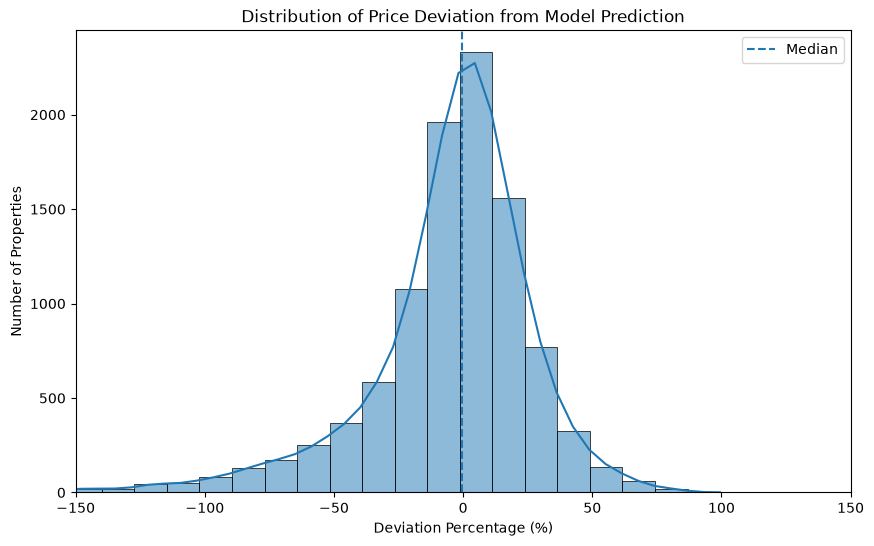

In [60]:
# Distribution of model-based price deviations

plt.figure(figsize=(10, 6))

sns.histplot(
    valid_anomaly_df["Deviation_Percentage"],
    bins=100,
    kde=True
)

plt.axvline(
    valid_anomaly_df["Deviation_Percentage"].median(),
    linestyle="--",
    label="Median"
)

plt.xlim(-150, 150)

plt.xlabel("Deviation Percentage (%)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Price Deviation from Model Prediction")
plt.legend()
plt.show()

In [61]:
# IQR-BASED ANOMALY THRESHOLDS

Q1 = valid_anomaly_df["Deviation_Percentage"].quantile(0.25)
Q3 = valid_anomaly_df["Deviation_Percentage"].quantile(0.75)

IQR = Q3 - Q1

lower_threshold_iqr = Q1 - 1.5 * IQR
upper_threshold_iqr = Q3 + 1.5 * IQR

print("IQR-Based Anomaly Thresholds")
print("=" * 50)
print(f"Q1                  : {Q1:.2f}%")
print(f"Q3                  : {Q3:.2f}%")
print(f"IQR                 : {IQR:.2f}%")
print(f"Underpriced cutoff  : {lower_threshold_iqr:.2f}%")
print(f"Overpriced cutoff   : {upper_threshold_iqr:.2f}%")

IQR-Based Anomaly Thresholds
Q1                  : -16.83%
Q3                  : 13.65%
IQR                 : 30.48%
Underpriced cutoff  : -62.56%
Overpriced cutoff   : 59.37%


In [62]:
# IQR-BASED PRICE CLASSIFICATION

def classify_price_iqr(deviation):
    if deviation < lower_threshold_iqr:
        return "Potentially Underpriced"
    elif deviation > upper_threshold_iqr:
        return "Potentially Overpriced"
    else:
        return "Fairly Priced"


valid_anomaly_df["Price_Category"] = (
    valid_anomaly_df["Deviation_Percentage"]
    .apply(classify_price_iqr)
)

invalid_anomaly_df["Price_Category"] = "Invalid Prediction"

final_anomaly_df = pd.concat(
    [valid_anomaly_df, invalid_anomaly_df],
    axis=0
).sort_index()

category_counts = (
    final_anomaly_df["Price_Category"]
    .value_counts()
)

category_percentages = (
    category_counts / len(final_anomaly_df) * 100
).round(2)

final_category_summary = pd.DataFrame({
    "Count": category_counts,
    "Percentage": category_percentages
})

display(final_category_summary)

,Count,Percentage
Price_Category,,
Fairly Priced,9313,93.13
Potentially Underpriced,581,5.81
Potentially Overpriced,98,0.98
Invalid Prediction,8,0.08


In [63]:
# CATEGORY-LEVEL PROPERTY PROFILE

analysis_df = final_anomaly_df[
    final_anomaly_df["Price_Category"] != "Invalid Prediction"
].copy()

category_profile = (
    analysis_df
    .groupby("Price_Category")
    .agg(
        Listings=("price", "size"),
        Median_Actual_Price=("price", "median"),
        Median_Predicted_Price=("Predicted_Price", "median"),
        Median_Area=("area_sqft", "median"),
        Median_BHK=("bhk", "median"),
        Median_Bathrooms=("bathrooms", "median"),
        Median_Parking=("parking", "median"),
        Median_Deviation=("Deviation_Percentage", "median")
    )
    .reindex([
        "Potentially Underpriced",
        "Fairly Priced",
        "Potentially Overpriced"
    ])
)

display(category_profile)

,Listings,Median_Actual_Price,Median_Predicted_Price,Median_Area,Median_BHK,Median_Bathrooms,Median_Parking,Median_Deviation
Price_Category,,,,,,,,
Potentially Underpriced,581,9500000.0,1.849306e+07,1345.0,2.5,2.0,1.0,-84.847953
Fairly Priced,9313,16370000.0,1.641025e+07,1345.0,3.0,2.0,1.0,1.096565
Potentially Overpriced,98,13700000.0,3.830340e+06,972.5,2.0,2.0,1.0,65.657541


In [64]:
# CATEGORICAL PROFILE OF PRICE CATEGORIES

print("FURNISHING DISTRIBUTION")
print("=" * 60)

furnishing_profile = pd.crosstab(
    analysis_df["Price_Category"],
    analysis_df["furnishing"],
    normalize="index"
) * 100

display(furnishing_profile.round(2))


print("\nCONSTRUCTION STATUS DISTRIBUTION")
print("=" * 60)

construction_profile = pd.crosstab(
    analysis_df["Price_Category"],
    analysis_df["is_under_construction"],
    normalize="index"
) * 100

display(construction_profile.round(2))

FURNISHING DISTRIBUTION


furnishing,Fully Furnished,Semi Furnished,Unfurnished
Price_Category,,,
Fairly Priced,4.58,52.74,42.67
Potentially Overpriced,5.10,67.35,27.55
Potentially Underpriced,3.61,61.96,34.42



CONSTRUCTION STATUS DISTRIBUTION


is_under_construction,False,True
Price_Category,,
Fairly Priced,83.03,16.97
Potentially Overpriced,82.65,17.35
Potentially Underpriced,87.78,12.22


In [65]:
# LOCATION-LEVEL ANOMALY ANALYSIS

location_analysis = (
    analysis_df
    .groupby(["location", "Price_Category"])
    .size()
    .unstack(fill_value=0)
)

# Ensure all expected columns exist
for col in [
    "Potentially Underpriced",
    "Fairly Priced",
    "Potentially Overpriced"
]:
    if col not in location_analysis.columns:
        location_analysis[col] = 0

location_analysis["Total"] = location_analysis.sum(axis=1)

location_analysis["Underpriced_Rate"] = (
    location_analysis["Potentially Underpriced"]
    / location_analysis["Total"] * 100
)

location_analysis["Overpriced_Rate"] = (
    location_analysis["Potentially Overpriced"]
    / location_analysis["Total"] * 100
)

# Locations with at least 5 listings
location_analysis_filtered = location_analysis[
    location_analysis["Total"] >= 5
].copy()

print("TOP LOCATIONS BY POTENTIALLY UNDERPRICED LISTINGS")
print("=" * 70)

display(
    location_analysis_filtered
    .sort_values(
        "Potentially Underpriced",
        ascending=False
    )
    .head(15)
)

print("TOP LOCATIONS BY POTENTIALLY OVERPRICED LISTINGS")
print("=" * 70)

display(
    location_analysis_filtered
    .sort_values(
        "Potentially Overpriced",
        ascending=False
    )
    .head(15)
)

TOP LOCATIONS BY POTENTIALLY UNDERPRICED LISTINGS


Price_Category,Fairly Priced,Potentially Overpriced,Potentially Underpriced,Total,Underpriced_Rate,Overpriced_Rate
location,,,,,,
"Phase I, Electronic City",177,0,22,199,11.055276,0.000000
"Dodsworth Layout, Whitefield",207,1,15,223,6.726457,0.448430
"Varthur, Bengaluru",140,0,14,154,9.090909,0.000000
"Sarjapur, Bengaluru",187,0,12,199,6.030151,0.000000
"NN Farm Layout, Sanjaynagar",9,2,8,19,42.105263,10.526316
"Balagere, Bengaluru",131,0,8,139,5.755396,0.000000
"Kaverappa Layout, Kadubeesanahalli",5,2,8,15,53.333333,13.333333
"Phase 2, Whitefield",36,0,7,43,16.279070,0.000000
"Attibele, Bengaluru",29,0,7,36,19.444444,0.000000


TOP LOCATIONS BY POTENTIALLY OVERPRICED LISTINGS


Price_Category,Fairly Priced,Potentially Overpriced,Potentially Underpriced,Total,Underpriced_Rate,Overpriced_Rate
location,,,,,,
"Sree Narayana Nagar, Kadagrahara",16,4,3,23,13.043478,17.391304
"Shriram Sameeksha, Singapura",21,3,0,24,0.000000,12.500000
"Terracon Doctors Enclave, Chandapura",30,3,3,36,8.333333,8.333333
"Hennagara, Bommasandra",11,3,0,14,0.000000,21.428571
"Electronic City, Bengaluru",11,3,1,15,6.666667,20.000000
"Pragathi Nagar, Basapura",9,2,1,12,8.333333,16.666667
"Kaverappa Layout, Kadubeesanahalli",5,2,8,15,53.333333,13.333333
"Someshwara Layout, Doddakannelli",13,2,1,16,6.250000,12.500000
"Thyvakanahally, Bengaluru",5,2,1,8,12.500000,25.000000


In [66]:
# AGE PROFILE OF PRICE CATEGORIES

age_profile = (
    analysis_df
    .groupby("Price_Category")
    .agg(
        Median_Age=("age_years", "median"),
        Mean_Age=("age_years", "mean"),
        Listings_With_Age=("age_years", "count")
    )
    .reindex([
        "Potentially Underpriced",
        "Fairly Priced",
        "Potentially Overpriced"
    ])
)

display(age_profile.round(2))

,Median_Age,Mean_Age,Listings_With_Age
Price_Category,,,
Potentially Underpriced,7.0,7.28,558
Fairly Priced,5.0,5.92,8075
Potentially Overpriced,4.1,6.84,93


In [67]:
# BHK DISTRIBUTION BY PRICE CATEGORY

bhk_profile = pd.crosstab(
    analysis_df["Price_Category"],
    analysis_df["bhk"],
    normalize="index"
) * 100

display(bhk_profile.round(2))

bhk,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,6.0,7.0,8.0,10.0,11.0,12.0
Price_Category,,,,,,,,,,,,,,,
Fairly Priced,3.94,0.28,40.08,1.59,45.18,1.90,5.94,0.45,0.50,0.02,0.01,0.04,0.02,0.01,0.02
Potentially Overpriced,7.14,0.00,54.08,0.00,31.63,0.00,7.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Potentially Underpriced,2.24,0.00,46.99,1.55,40.45,1.03,6.02,0.17,0.69,0.00,0.00,0.34,0.34,0.17,0.00
